## Importy


In [8]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import math
import ipywidgets as widgets
import os

from utils.sinogram import show_sinogram, scan_generate_sinogram
from utils.filter import filter_sinogram
from utils.image_reconstruction import reconstruct_image, show_image

## Wybór zdjęcia


In [9]:

folder_path = './src/example_images/'

images_list = [
    f for f in os.listdir(folder_path) 
    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif'))
]

dropdown = widgets.Dropdown(
    options=images_list,
    value='SADDLE_PE-large.JPG',
    description='Obraz:',
)


output_area = widgets.Output() # Tutaj będą się pojawiać obrazki i napisy
img_height, img_width = 0, 0
# 3. Funkcja logiki
def process_image(file_name):
    global img_height, img_width, img_matrix
    plt.close('all')
    with output_area:
        clear_output(wait=True) # Czyścimy tylko obszar pod menu
        file_path = f'{folder_path}{file_name}'
        
        try:
            img = Image.open(file_path).convert('L')
            img_matrix = np.array(img) / 255
            img_height, img_width = img_matrix.shape
            
            print(f"Plik: {file_name} | Rozmiar: {img_height}x{img_width}")
            
            plt.figure(figsize=(6, 6))
            plt.imshow(img_matrix, cmap='gray')
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Błąd ładowania pliku {file_name}: {e}")

# 4. Obsługa zdarzenia zmiany
def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        process_image(change['new'])

dropdown.observe(on_change)

# 5. Wyświetlenie wszystkiego
display(dropdown)
display(output_area)

# Wywołanie startowe
process_image(dropdown.value)

Dropdown(description='Obraz:', index=6, options=('CT_ScoutView-large.jpg', 'CT_ScoutView.jpg', 'Kolo.jpg', 'Kr…

Output()

## Parametry wejściowe


In [ ]:
N_detectors = 180
N_scans = 180
angle_coverage = 180    #degrees
l = math.sqrt(pow(img_width,2)+pow(img_height,2))



# Tomograf

## Tworzenie Singoramu


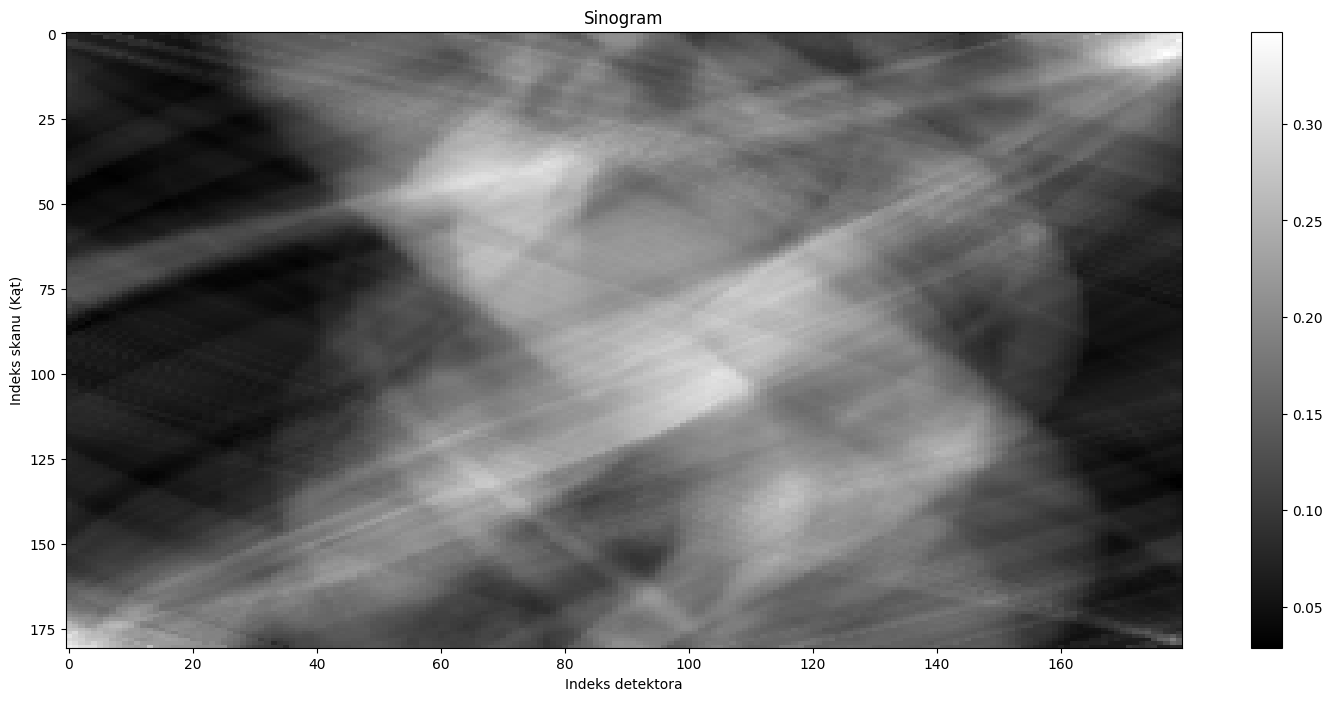

In [11]:
sinogram = scan_generate_sinogram(N_detectors, l, angle_coverage, N_scans, img_matrix)

show_sinogram(sinogram)

## Filtr


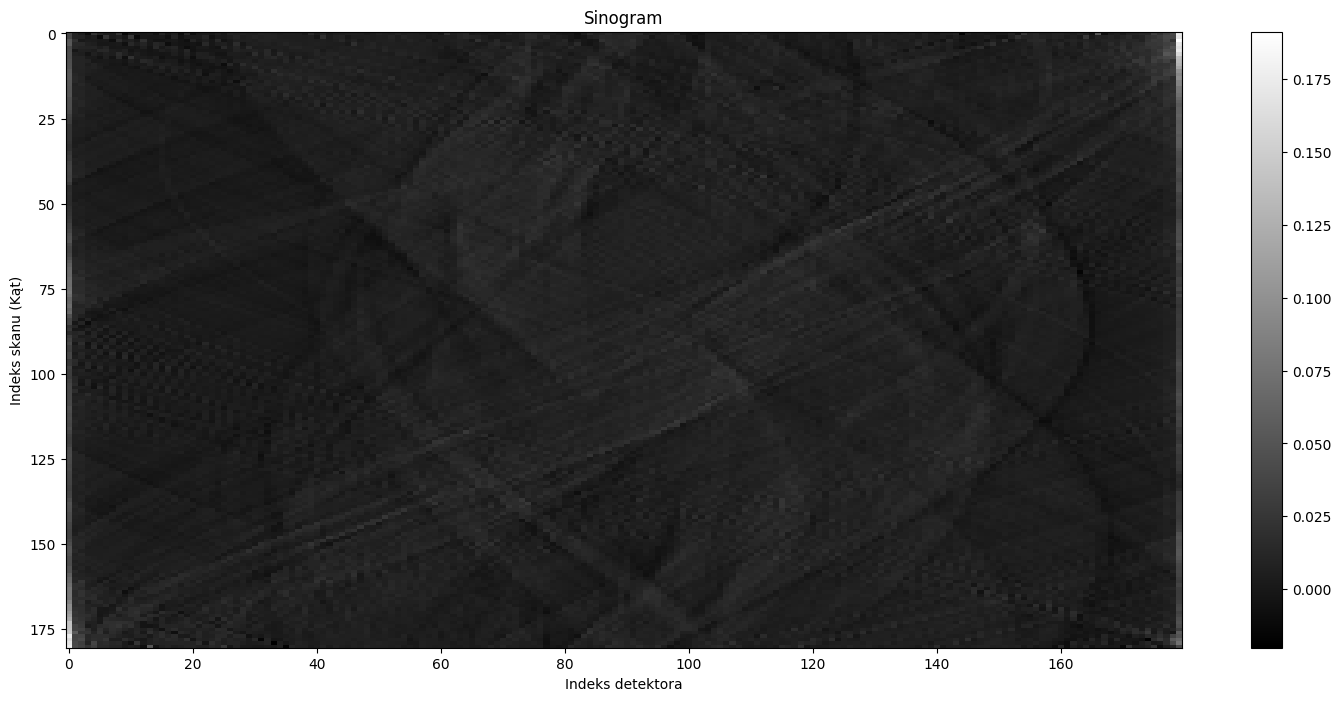

In [12]:
filtered_sinogram = filter_sinogram(sinogram)

show_sinogram(filtered_sinogram)

## Obraz wyjściowy (bez filtra)


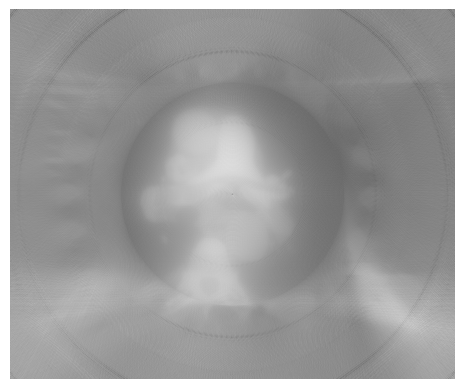

In [13]:
reconstructed_image_NOfilter_matrix = reconstruct_image(angle_coverage, img_matrix, N_detectors, l, N_scans, sinogram, rescale= False)

show_image(reconstructed_image_NOfilter_matrix)

## Obraz wyjściowy (z filtrem)

In [ ]:
reconstructed_image_filtered_matrix = reconstruct_image(angle_coverage, img_matrix, N_detectors, l, N_scans, filtered_sinogram, rescale = True)

show_image(reconstructed_image_filtered_matrix)